In [78]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [79]:
import sys
!{sys.executable} -m ipykernel install --user --name CS666 --display-name "Python (CS666)"

Installed kernelspec CS666 in /pomplun/share_home/fidelia.osei001/.local/share/jupyter/kernels/cs666


In [80]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [81]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [82]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-24 18:17:41--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to cs666.org (cs666.org)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz.4’

mito.npz.4          100%[===================>]  35.87M  88.1MB/s    in 0.4s    

2026-04-24 18:17:42 (88.1 MB/s) - ‘mito.npz.4’ saved [37610178/37610178]



In [83]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [84]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [85]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

#The code loads the dataset from a .npz file, which contains both images and their corresponding segmentation masks. It then normalizes the image pixel values to a range between 0 and 1 using min-max normalization. Finally, it converts the masks into binary values (True/False) and then into floating-point format for further processing.

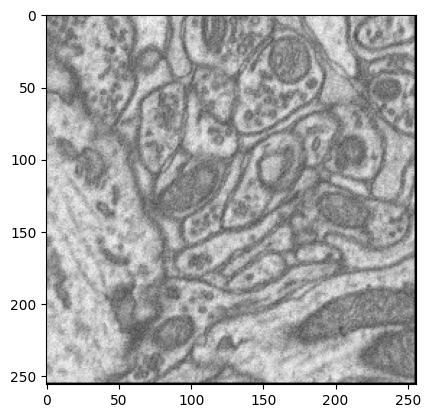

In [86]:
imshow(images[0], cmap='gray')

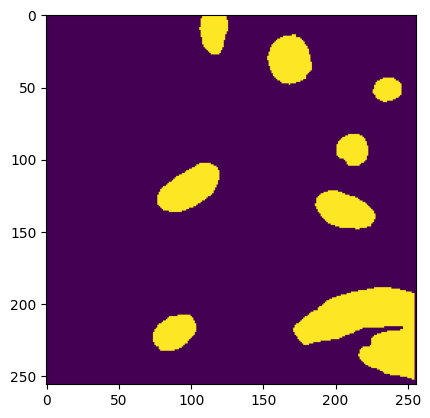

In [87]:
imshow(masks[0])

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [89]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

#The code splits the dataset into training, validation, and test sets. First, it separates 70% of the data for training and 30% into a temporary set. Then, the temporary set is split equally into validation and test sets. This ensures that the model is trained on one portion of the data, validated during training, and finally evaluated on unseen test data.

## 2. Make the Data Pytorch-ready! (10 points)

In [90]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [91]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [92]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

#The code defines data transformations for training and validation using the Albumentations library. For the training data, it applies random augmentations such as horizontal flipping, vertical flipping, and 90-degree rotations to increase data diversity and improve model generalization. Each transformation is applied with a probability of 0.5. For the validation data, no transformations are applied, ensuring that evaluation is performed on the original, unmodified data.

In [93]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [94]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [95]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER

#The code defines data transformations for training and validation using the Albumentations library. For the training data, it applies random augmentations such as horizontal flipping, vertical flipping, and 90-degree rotations to increase data diversity and improve model generalization. Each transformation is applied with a probability of 0.5. For the validation data, no transformations are applied, ensuring that evaluation is performed on the original, unmodified data.

## 3. Configure the Classifier! (30 points)

In [96]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [97]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [98]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [99]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [100]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.4268, train_dice=0.6466 | val_loss=0.6132, val_dice=0.3599
Epoch 2/10 | train_loss=0.1807, train_dice=0.8291 | val_loss=0.1508, val_dice=0.8406
Epoch 3/10 | train_loss=0.1072, train_dice=0.8769 | val_loss=0.1436, val_dice=0.8106
Epoch 4/10 | train_loss=0.0875, train_dice=0.8906 | val_loss=0.1038, val_dice=0.8673
Epoch 5/10 | train_loss=0.0770, train_dice=0.9008 | val_loss=0.0667, val_dice=0.9122
Epoch 6/10 | train_loss=0.0614, train_dice=0.9208 | val_loss=0.0572, val_dice=0.9250
Epoch 7/10 | train_loss=0.0557, train_dice=0.9285 | val_loss=0.0518, val_dice=0.9312
Epoch 8/10 | train_loss=0.0579, train_dice=0.9215 | val_loss=0.0505, val_dice=0.9356
Epoch 9/10 | train_loss=0.0531, train_dice=0.9292 | val_loss=0.0656, val_dice=0.9000
Epoch 10/10 | train_loss=0.0485, train_dice=0.9344 | val_loss=0.0412, val_dice=0.9478
Best val dice: 0.9478292465209961


In [101]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

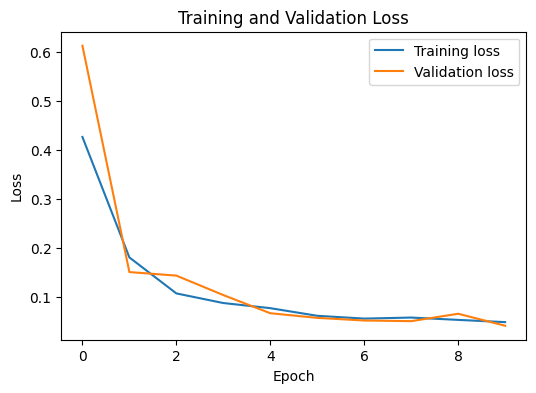

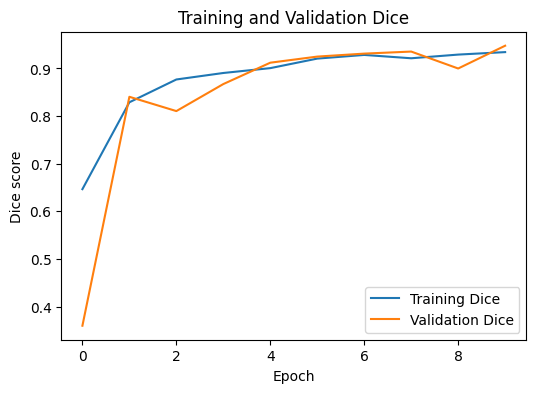

In [102]:
import matplotlib.pyplot as plt

# Loss curves
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Dice curves
plt.figure(figsize=(6,4))
plt.plot(train_dices, label="Training Dice")
plt.plot(val_dices, label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice score")
plt.title("Training and Validation Dice")
plt.legend()
plt.show()

In [103]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER

#Yes, the plots look good. The training and validation losses both decrease steadily, showing that the model is learning. The training and validation Dice scores also increase over time and reach high values around 0.94, which means the predicted masks overlap well with the ground truth masks. Since the training and validation curves are close to each other, the model appears to generalize well without strong overfitting.

## 5. Testing the U-Net. (20 points)

In [104]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0392
Test dice: 0.9505


In [105]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

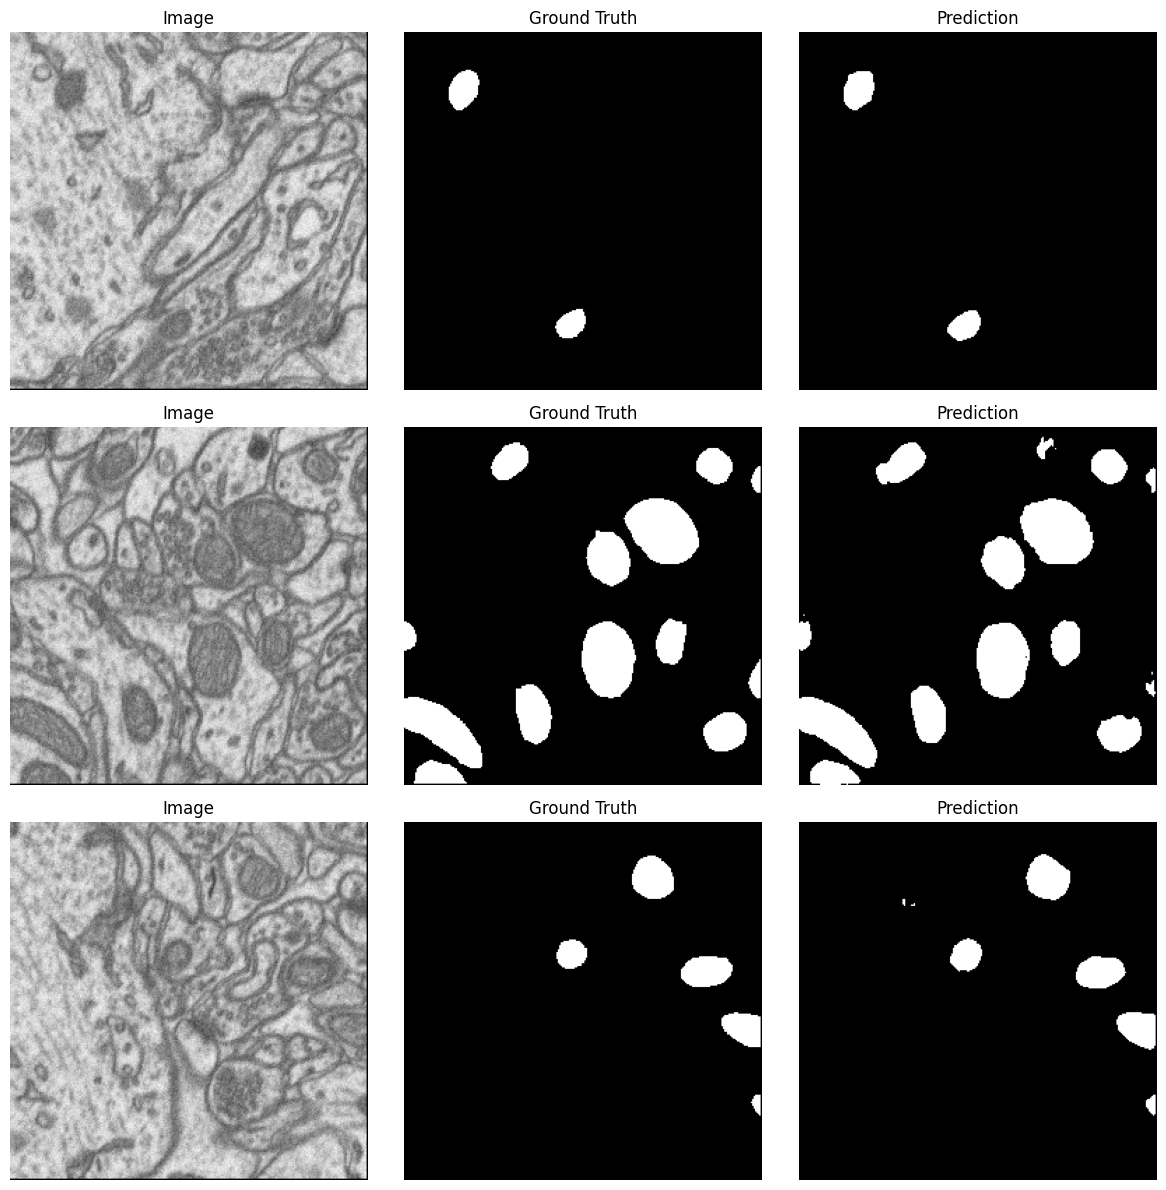

In [106]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [107]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER

#Yes, the classifier works well. The predicted masks closely match the ground truth masks in terms of shape, size, and location of the mitochondria. The model is able to correctly identify multiple objects and produces clean segmentations with minimal noise. This is also supported by the high test Dice score (~0.94), indicating strong overlap between predictions and ground truth. Overall, the classifier demonstrates good performance and generalization.

## Bonus: Improve the results. (33 points)

In [108]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!

In [109]:
# BONUS: Improve results

# Rebuild a stronger model
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.3 * bce_loss(pred, target) + 0.7 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 20

best_val_dice = 0.0
bonus_train_losses, bonus_val_losses = [], []
bonus_train_dices, bonus_val_dices = [], []

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    bonus_train_losses.append(train_loss)
    bonus_val_losses.append(val_loss)
    bonus_train_dices.append(train_dice)
    bonus_val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model_bonus.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best bonus val dice:", best_val_dice)

# Evaluate improved model on test data
model.load_state_dict(torch.load("best_mito_model_bonus.pth", map_location=device))
test_loss_bonus, test_dice_bonus = run_epoch(model, test_loader, optimizer=None)

print("Improved test loss:", round(test_loss_bonus, 4))
print("Improved test dice:", round(test_dice_bonus, 4))

Epoch 1/20 | train_loss=0.6404, train_dice=0.4950 | val_loss=1.4631, val_dice=0.1481
Epoch 2/20 | train_loss=0.4288, train_dice=0.7775 | val_loss=0.4216, val_dice=0.7133
Epoch 3/20 | train_loss=0.2948, train_dice=0.8351 | val_loss=0.2360, val_dice=0.8789
Epoch 4/20 | train_loss=0.1898, train_dice=0.8866 | val_loss=0.1551, val_dice=0.9046
Epoch 5/20 | train_loss=0.1443, train_dice=0.8948 | val_loss=0.1983, val_dice=0.7930
Epoch 6/20 | train_loss=0.1268, train_dice=0.8908 | val_loss=0.1175, val_dice=0.8963
Epoch 7/20 | train_loss=0.1026, train_dice=0.9078 | val_loss=0.0898, val_dice=0.9211
Epoch 8/20 | train_loss=0.0895, train_dice=0.9160 | val_loss=0.0867, val_dice=0.9139
Epoch 9/20 | train_loss=0.0815, train_dice=0.9209 | val_loss=0.0933, val_dice=0.9021
Epoch 10/20 | train_loss=0.0683, train_dice=0.9326 | val_loss=0.0647, val_dice=0.9365
Epoch 11/20 | train_loss=0.0651, train_dice=0.9349 | val_loss=0.0603, val_dice=0.9368
Epoch 12/20 | train_loss=0.0643, train_dice=0.9324 | val_loss=0

In [110]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#